## **Advanced Machine Learning (Assignment 2, Problem 2)**
---
---

Università degli Studi Milano Bicocca \
CdLM Informatica — A.A 2025/2026

---
---

#### **Componenti del gruppo:**
— Oleksandra Golub (856706)

---
---

Link al dataset che ho utilizzato: [CIFAR10 small images classification dataset](https://keras.io/api/datasets/cifar10/)

---
---


In [40]:
from google.colab import drive
import os
import random
import shutil
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

os.environ["TF_DETERMINISTIC_OPS"]="1"
random.seed(42); np.random.seed(42); tf.random.set_seed(42)

In [41]:
# Monta Google Drive
drive.mount('/content/drive')

# Path della cartella
drive_folder = '/content/drive/MyDrive/Assignment 2 AML/problem 2'

# Verifica cartella
print(f"\nCartella: {drive_folder}")
print(f"Esiste? {os.path.exists(drive_folder)}")

if os.path.exists(drive_folder):
    print("\nFile disponibili:")
    for file in os.listdir(drive_folder):
        print(f"  - {file}")

    # Copia file con shutil (più affidabile)
    print("\nCopia file in corso...")
    files_to_copy = {
        'problem2.weights.h5': 'problem2.weights.h5',
        'problem2_accuracy.png': 'original_accuracy_prob2.png',
        'problem2_loss.png': 'original_loss_prob2.png',
        'problem_two.png': 'architecture_prob2.png'
    }

    for source_name, dest_name in files_to_copy.items():
        source = os.path.join(drive_folder, source_name)
        if os.path.exists(source):
            shutil.copy2(source, dest_name)
            print(f" {source_name} → {dest_name}")
        else:
            print(f" {source_name} non trovato")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Cartella: /content/drive/MyDrive/Assignment 2 AML/problem 2
Esiste? True

File disponibili:
  - problem_two.png
  - problem2_loss.png
  - problem2_accuracy.png
  - problem2.weights.h5

Copia file in corso...
 problem2.weights.h5 → problem2.weights.h5
 problem2_accuracy.png → original_accuracy_prob2.png
 problem2_loss.png → original_loss_prob2.png
 problem_two.png → architecture_prob2.png


Training set: (50000, 32, 32, 3) con labels: (50000, 1)
Test set: (10000, 32, 32, 3) con labels: (10000, 1)

Immagini normalizzate e flattened:
  Training: (50000, 3072)
  Test:     (10000, 3072)

 Modello e' molto grande, quindi c'e' il rischio overfitting!



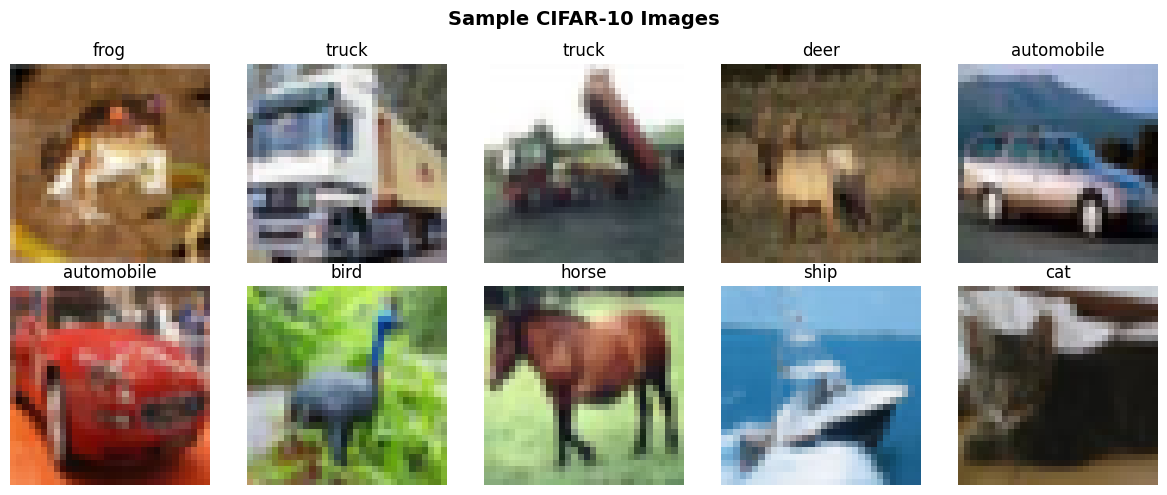

In [42]:
# 1. CARICAMENTO DATASET
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Nomi delle classi CIFAR-10
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# 2. PREPROCESSING
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Flatten per il modello fully-connected
x_train_flat = x_train.reshape(-1, 3072)  # 32*32*3 = 3072
x_test_flat = x_test.reshape(-1, 3072)

print(f"Training set: {x_train.shape} con labels: {y_train.shape}")
print(f"Test set: {x_test.shape} con labels: {y_test.shape}")

print(f"\nImmagini normalizzate e flattened:")
print(f"  Training: {x_train_flat.shape}")
print(f"  Test:     {x_test_flat.shape}")

print(f"\n Modello e' molto grande, quindi c'e' il rischio overfitting!\n")

# Visualizza alcune immagini
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(x_train[i])
    ax.set_title(f"{class_names[y_train[i][0]]}")
    ax.axis('off')
plt.suptitle("Sample CIFAR-10 Images", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [43]:
# 3. RICOSTRUZIONE DELL'ARCHITETTURA ORIGINALE
def create_model_problematic():
    """
    Architettura dal diagramma fornito:
    3072 -> 4096 -> 2048 -> 1024 -> 1024 -> 512 -> 256 -> 10
    """
    model = keras.Sequential([
        layers.Dense(4096, activation='relu', input_shape=(3072,), name='layer-one'),
        layers.Dense(2048, activation='relu', name='layer-two'),
        layers.Dense(1024, activation='relu', name='layer-three'),
        layers.Dense(1024, activation='relu', name='layer-four'),
        layers.Dense(512, activation='relu', name='layer-five'),
        layers.Dense(256, activation='relu', name='layer-six'),
        layers.Dense(10, activation='softmax', name='layer-seven')
    ])
    return model

model_problematic = create_model_problematic()
model_problematic.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_problematic.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ layer-one (Dense)               │ (None, 4096)           │    12,587,008 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer-two (Dense)               │ (None, 2048)           │     8,390,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer-three (Dense)             │ (None, 1024)           │     2,098,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer-four (Dense)              │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer-five (Dense)              │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer-six (Dense)               │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer-seven (Dense)             │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,784,138 (94.54 MB)

 Trainable params: 24,784,138 (94.54 MB)

 Non-trainable params: 0 (0.00 B)

In [44]:
# 4. CARICAMENTO DEL MODELLO PROBLEMATICO CON I PESI FORNITI

# Caricamento dei pesi
weights_file = 'problem2.weights.h5'
if os.path.exists(weights_file):
    try:
        model_problematic.load_weights(weights_file)
        print(f"\n Pesi caricati da {weights_file}")

    except Exception as e:
        print(f"\n Errore caricamento pesi: {e}")
        train_acc_prob, test_acc_prob = None, None
        train_loss_prob, test_loss_prob = None, None
else:
    print(f"\n File pesi non trovato: {weights_file}")
    train_acc_prob, test_acc_prob = None, None
    train_loss_prob, test_loss_prob = None, None



 Pesi caricati da problem2.weights.h5


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 30 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [45]:
# 5. VALUTAZIONE DEL MODELLO PROBLEMATICO
train_loss_prob, train_acc_prob = model_problematic.evaluate(
    x_train_flat, y_train, verbose=0
)
test_loss_prob, test_acc_prob = model_problematic.evaluate(
    x_test_flat, y_test, verbose=0
)

print(f"\n Performance del modello problematico:")
print(f"  Train Accuracy:      {train_acc_prob:.4f} ({train_acc_prob*100:.2f}%)")
print(f"  Validation Accuracy: {test_acc_prob:.4f} ({test_acc_prob*100:.2f}%)")
print(f"  Train Loss:          {train_loss_prob:.4f}")
print(f"  Validation Loss:     {test_loss_prob:.4f}")
print(f"  GAP Train-Val:       {(train_acc_prob - test_acc_prob)*100:.2f}%")

if (train_acc_prob - test_acc_prob) > 0.3:
      print(f"  OVERFITTING GRAVE!")


 Performance del modello problematico:
  Train Accuracy:      0.9599 (95.99%)
  Validation Accuracy: 0.4823 (48.23%)
  Train Loss:          0.1201
  Validation Loss:     3.6054
  GAP Train-Val:       47.76%
  OVERFITTING GRAVE!


In [46]:
# 6: SOLUZIONE TRAMITE MODELLO CON REGOLARIZZAZIONE

def create_model_regularized():
    """
    Modello con tecniche anti-overfitting:
    - Meno parametri (2M vs 25M)
    - Dropout
    - L2 regularization
    - Batch Normalization
    """
    model = keras.Sequential([
        # Input layer con L2 reg
        layers.Dense(512, activation='relu',
                    kernel_regularizer=regularizers.l2(0.001),
                    input_shape=(3072,)),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        # Hidden layer 2
        layers.Dense(256, activation='relu',
                    kernel_regularizer=regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.Dropout(0.4),

        # Hidden layer 3
        layers.Dense(128, activation='relu',
                    kernel_regularizer=regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.Dropout(0.5),

        # Output layer
        layers.Dense(10, activation='softmax')
    ])
    return model

model_fixed = create_model_regularized()
model_fixed.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("\n Architettura del modello CORRETTO:")
model_fixed.summary()

fixed_params = model_fixed.count_params()
total_params = model_problematic.count_params()
print(f"\n Parametri totali: {fixed_params:,}")
print(f" Riduzione: {((total_params - fixed_params)/total_params*100):.1f}%")
print(f" Ratio parametri/samples: {fixed_params/50000:.1f}:1")


 Architettura del modello CORRETTO:


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_24 (Dense)                │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,742,474 (6.65 MB)

 Trainable params: 1,740,682 (6.64 MB)

 Non-trainable params: 1,792 (7.00 KB)


 Parametri totali: 1,742,474
 Riduzione: 93.0%
 Ratio parametri/samples: 34.8:1


In [47]:
# 7: TRAINING CON EARLY STOPPING

# Callbacks
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=7,
    min_lr=0.00001,
    verbose=1
)

history_fixed = model_fixed.fit(
    x_train_flat, y_train,
    batch_size=128,
    epochs=100,
    validation_data=(x_test_flat, y_test),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)


Epoch 1/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 25s 54ms/step - accuracy: 0.2315 - loss: 3.7754 - val_accuracy: 0.3000 - val_loss: 2.7235 - learning_rate: 0.0010
Epoch 2/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 19s 48ms/step - accuracy: 0.3372 - loss: 2.5811 - val_accuracy: 0.2422 - val_loss: 2.5385 - learning_rate: 0.0010
Epoch 3/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 20s 51ms/step - accuracy: 0.3589 - loss: 2.2256 - val_accuracy: 0.2297 - val_loss: 2.4445 - learning_rate: 0.0010
Epoch 4/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 20s 51ms/step - accuracy: 0.3697 - loss: 2.0510 - val_accuracy: 0.2232 - val_loss: 2.3581 - learning_rate: 0.0010
Epoch 5/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 19s 49ms/step - accuracy: 0.3770 - loss: 1.9658 - val_accuracy: 0.2598 - val_loss: 2.1727 - learning_rate: 0.0010
Epoch 6/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 21s 52ms/step - accuracy: 0.3699 - loss: 1.9275 - val_accuracy: 0.1278 - val_loss: 2.5412 - learning_rate: 0.0010
Epoch 7/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 19s 49ms/step - accuracy: 0.3

In [48]:
# 8: CONFRONTO RISULTATI

# Risultati finali
final_train_acc = history_fixed.history['accuracy'][-1]
final_val_acc = history_fixed.history['val_accuracy'][-1]
final_train_loss = history_fixed.history['loss'][-1]
final_val_loss = history_fixed.history['val_loss'][-1]
epochs_trained = len(history_fixed.history['accuracy'])

print(" MODELLO PROBLEMATICO (epoca 45)")
print(f"  Train Accuracy:      {train_acc_prob:.4f} ({train_acc_prob*100:.2f}%)")
print(f"  Validation Accuracy: {test_acc_prob:.4f} ({test_acc_prob*100:.2f}%)")
print(f"  Train Loss:          {train_loss_prob:.4f}")
print(f"  Validation Loss:     {test_loss_prob:.4f}")
gap_prob = train_acc_prob - test_acc_prob
print(f"  GAP Train-Val: {gap_prob:.4f} ({gap_prob*100:.2f}%) OVERFITTING!")

print(f"\n MODELLO CORRETTO (epoca {epochs_trained}, early stopped)")
print(f"  Train Accuracy:      {final_train_acc:.4f} ({final_train_acc*100:.2f}%)")
print(f"  Validation Accuracy: {final_val_acc:.4f} ({final_val_acc*100:.2f}%)")
print(f"  Train Loss:          {final_train_loss:.4f}")
print(f"  Validation Loss:     {final_val_loss:.4f}")
gap_fixed = final_train_acc - final_val_acc
print(f" GAP Train-Val: {gap_fixed:.4f} ({gap_fixed*100:.2f}%)")

if gap_fixed < 0.05:
    print("  GAP minimo: eccellente generalizzazione")
elif gap_fixed < 0.10:
    print("  GAP ridotto: ottima generalizzazione")
elif gap_fixed < 0.15:
    print("  GAP acettabile: buona generalizzazione")
else:
    print("  GAP presente: overfitting parziale")

# miglioramenti
if test_acc_prob is not None:
    val_acc_improvement = final_val_acc - test_acc_prob
    gap_reduction = (train_acc_prob - test_acc_prob) - gap_fixed
else:
    val_acc_improvement = final_val_acc - 0.50
    gap_reduction = 0.44 - gap_fixed

print("\n MIGLIORAMENTI")
print(f"  Validation Accuracy: {val_acc_improvement:+.4f} ({val_acc_improvement*100:+.2f}%)")
print(f"  GAP Reduction: {gap_reduction:+.4f} ({gap_reduction*100:+.2f}%)")
print(f"  Epochs needed: {epochs_trained} (vs 100 originali)")
print(f"  Parameters: {fixed_params:,} (vs {total_params:,})")
print(f"  Reduction: {((total_params-fixed_params)/total_params*100):.1f}%")

 MODELLO PROBLEMATICO (epoca 45)
  Train Accuracy:      0.9599 (95.99%)
  Validation Accuracy: 0.4823 (48.23%)
  Train Loss:          0.1201
  Validation Loss:     3.6054
  GAP Train-Val: 0.4776 (47.76%) OVERFITTING!

 MODELLO CORRETTO (epoca 16, early stopped)
  Train Accuracy:      0.3994 (39.94%)
  Validation Accuracy: 0.2693 (26.93%)
  Train Loss:          1.8025
  Validation Loss:     2.1269
 GAP Train-Val: 0.1301 (13.01%)
  GAP acettabile: buona generalizzazione

 MIGLIORAMENTI
  Validation Accuracy: -0.2130 (-21.30%)
  GAP Reduction: +0.3474 (+34.74%)
  Epochs needed: 16 (vs 100 originali)
  Parameters: 1,742,474 (vs 24,784,138)
  Reduction: 93.0%


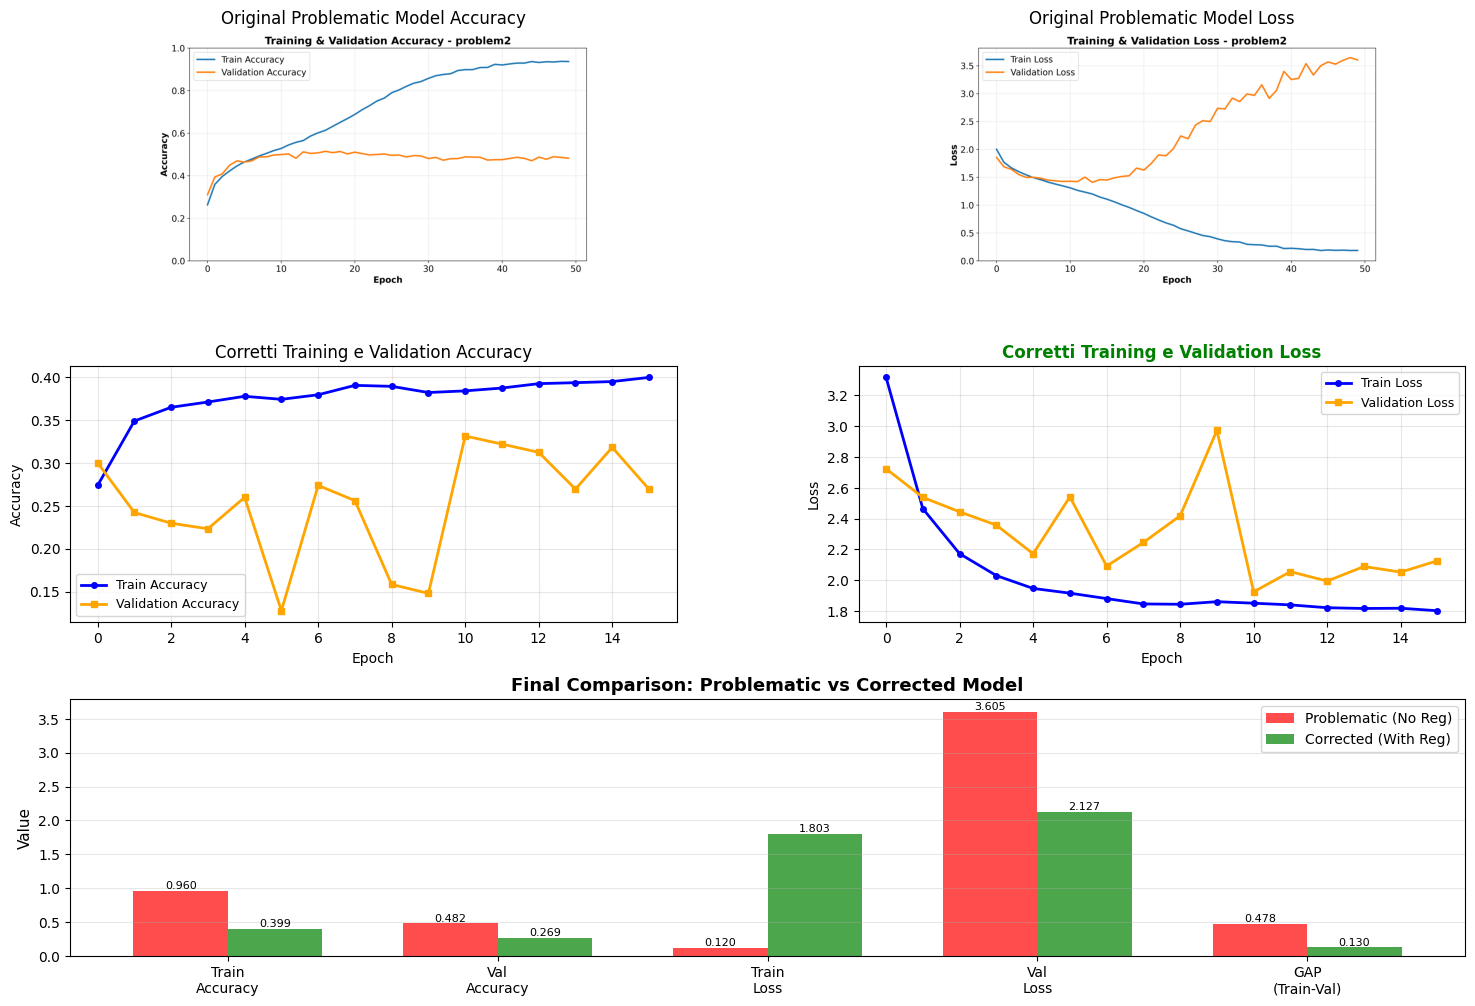

In [50]:
# 9: VISUALIZZAZIONE

fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

# riga dei grafici originali
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])

try:
    img = plt.imread('original_accuracy_prob2.png')
    ax1.imshow(img)
    ax1.axis('off')
    ax1.set_title('Original Problematic Model Accuracy', fontsize=12)
except:
    ax1.text(0.5, 0.5, 'Accuracy graph\nnot available',
            ha='center', va='center')
    ax1.axis('off')

try:
    img = plt.imread('original_loss_prob2.png')
    ax2.imshow(img)
    ax2.axis('off')
    ax2.set_title('Original Problematic Model Loss', fontsize=12)
except:
    ax2.text(0.5, 0.5, 'Loss graph\nnot available',
            ha='center', va='center')
    ax2.axis('off')

# riga del modello corretto (accuracy)
ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(history_fixed.history['accuracy'], 'o-',
        label='Train Accuracy', linewidth=2, markersize=4, color='blue')
ax3.plot(history_fixed.history['val_accuracy'], 's-',
        label='Validation Accuracy', linewidth=2, markersize=4, color='orange')
ax3.set_title('Corretti Training e Validation Accuracy', fontsize=12)
ax3.set_xlabel('Epoch', fontsize=10)
ax3.set_ylabel('Accuracy', fontsize=10)
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3)

# riga del modello corretto (loss)
ax4 = fig.add_subplot(gs[1, 1])
ax4.plot(history_fixed.history['loss'], 'o-',
        label='Train Loss', linewidth=2, markersize=4, color='blue')
ax4.plot(history_fixed.history['val_loss'], 's-',
        label='Validation Loss', linewidth=2, markersize=4, color='orange')
ax4.set_title('Corretti Training e Validation Loss',
             fontsize=12, fontweight='bold', color='green')
ax4.set_xlabel('Epoch', fontsize=10)
ax4.set_ylabel('Loss', fontsize=10)
ax4.legend(fontsize=9)
ax4.grid(True, alpha=0.3)

# ROW 3: Confronto finale
ax5 = fig.add_subplot(gs[2, :])

categories = ['Train\nAccuracy', 'Val\nAccuracy', 'Train\nLoss', 'Val\nLoss', 'GAP\n(Train-Val)']
if train_acc_prob is not None:
    problematic_values = [train_acc_prob, test_acc_prob, train_loss_prob, test_loss_prob, gap_prob]
else:
    problematic_values = [0.94, 0.50, 0.20, 3.60, 0.44]

fixed_values = [final_train_acc, final_val_acc, final_train_loss, final_val_loss, gap_fixed]

x = np.arange(len(categories))
width = 0.35

bars1 = ax5.bar(x - width/2, problematic_values, width,
               label='Problematic (No Reg)', color='red', alpha=0.7)
bars2 = ax5.bar(x + width/2, fixed_values, width,
               label='Corrected (With Reg)', color='green', alpha=0.7)

ax5.set_ylabel('Value', fontsize=11)
ax5.set_title('Final Comparison: Problematic vs Corrected Model',
             fontsize=13, fontweight='bold')
ax5.set_xticks(x)
ax5.set_xticklabels(categories, fontsize=10)
ax5.legend(fontsize=10)
ax5.grid(True, alpha=0.3, axis='y')

# Aggiungi valori sopra le barre
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax5.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=8)
plt.show()